First 5 records:
   Experience Education             Role      Department  Age  Salary
0           1   Diploma       IT Support              IT   22   22000
1           3  Bachelor    Web Developer     Development   25   35000
2           6    Master   System Analyst              IT   30   60000
3           2  Bachelor      QA Engineer         Testing   24   32000
4           5    Master  DevOps Engineer  Infrastructure   29   72000

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Experience  15 non-null     int64 
 1   Education   15 non-null     object
 2   Role        15 non-null     object
 3   Department  15 non-null     object
 4   Age         15 non-null     int64 
 5   Salary      15 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 848.0+ bytes
None

Missing Values:
 Experience    0
Education     0
Role          0
Dep

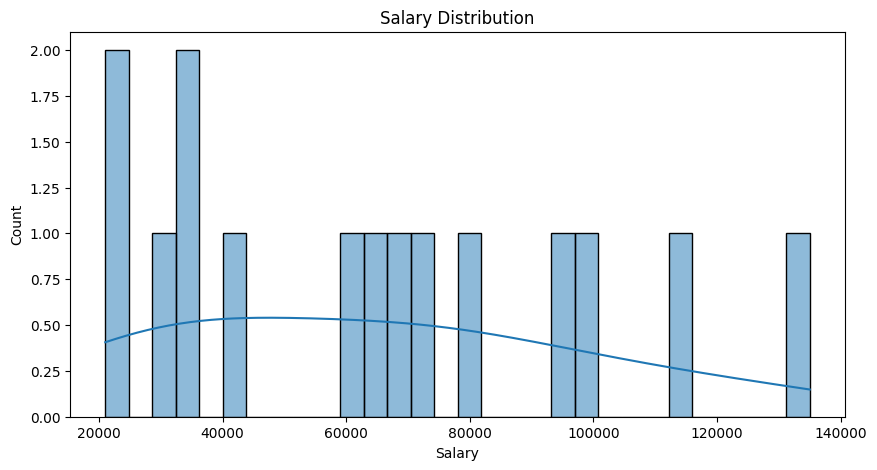

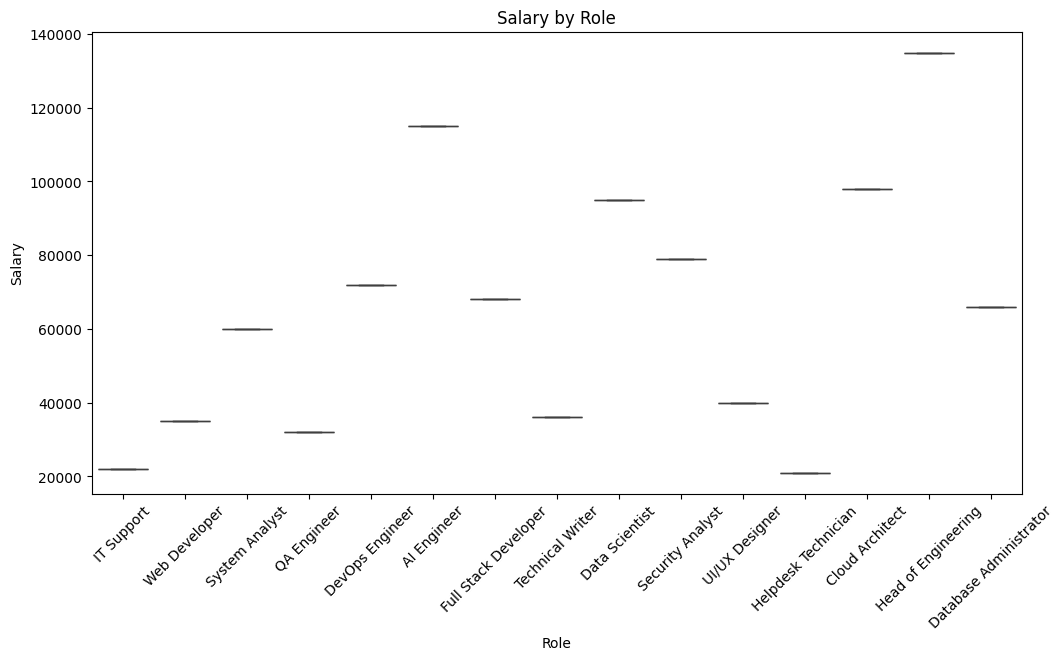

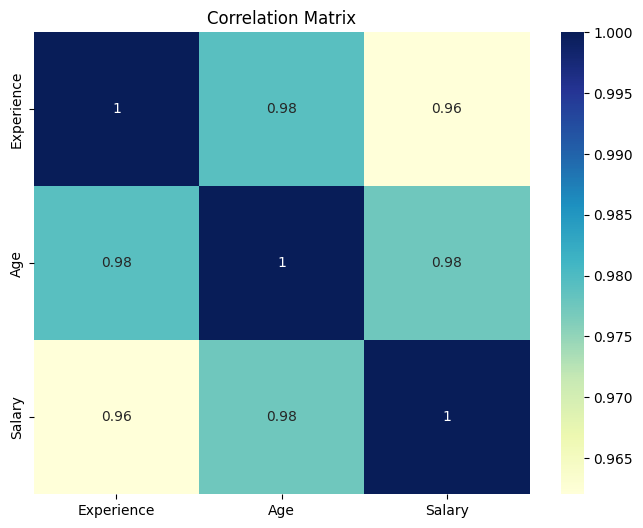

Model Evaluation:
MAE: 13791.66666666667
MSE: 325977986.1111112
R² Score: 0.5317903167890199


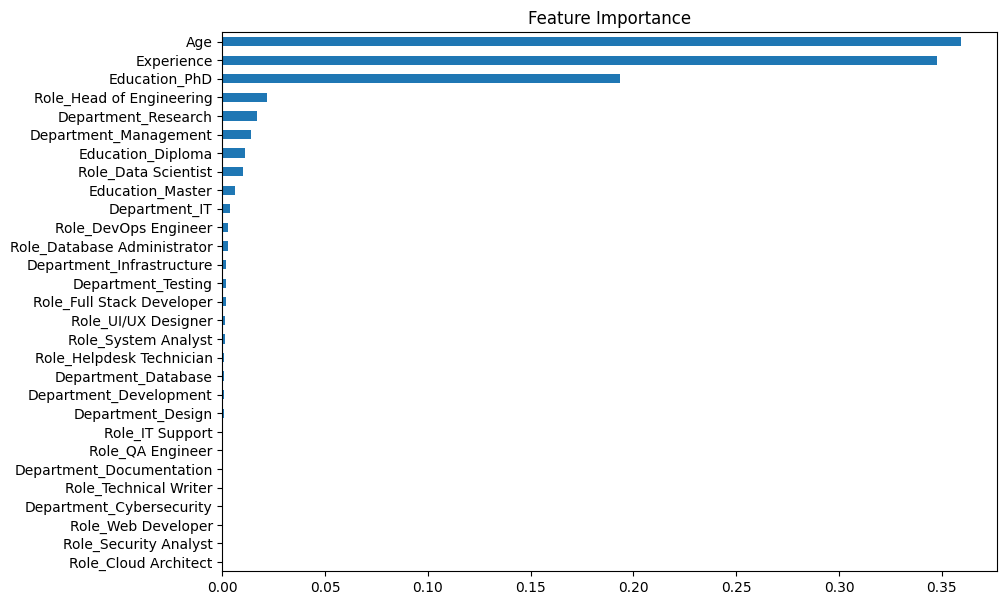

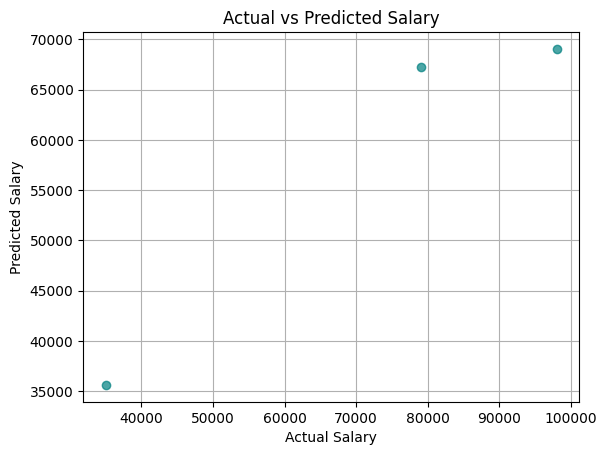

['employee_salary_analysis_model.pkl']

In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Dataset
df = pd.read_csv("data1.csv")
print("First 5 records:")
print(df.head())

# 3. Data Analysis
print("\nData Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

# 4. Visual Analysis
plt.figure(figsize=(10, 5))
sns.histplot(df["Salary"], kde=True, bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

# Boxplot: Salary vs Role
if 'Role' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Role", y="Salary", data=df)
    plt.xticks(rotation=45)
    plt.title("Salary by Role")
    plt.show()

# Correlation Heatmap (numerical only)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.title("Correlation Matrix")
plt.show()

# 5. Encode Categorical Data
df_encoded = pd.get_dummies(df, drop_first=True)

# 6. Split Dataset
X = df_encoded.drop("Salary", axis=1)
y = df_encoded["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# 7. Random Forest Regressor
model = RandomForestRegressor(n_estimators=120, random_state=100)
model.fit(X_train, y_train)

# 8. Predictions and Evaluation
y_pred = model.predict(X_test)

print("Model Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# 9. Feature Importance
feature_imp = pd.Series(model.feature_importances_, index=X.columns)
feature_imp.sort_values(ascending=True).plot(kind='barh', figsize=(10, 7))
plt.title("Feature Importance")
plt.show()

# 10. Actual vs Predicted Plot
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.grid(True)
plt.show()

# 11. Save the Model
import joblib
joblib.dump(model, "employee_salary_analysis_model.pkl")
